### 1. DESCRIPTION

**Movie Recommendation System**

This project develops a movie recommendation system that suggests relevant movies using multiple recommendation approaches, including Content-Based Filtering, K-Nearest Neighbors (KNN), Collaborative Filtering (SVD), and a Hybrid model. The system analyzes movie features such as genres and ratings to identify similarities and generate personalized recommendations.

---

**Total Rows**: 4,803 movies

**Movies features**: 20 columns

**Credits features**: 4 columns

**Source**: TMDB Movie Metadata - Kaggle (https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

---

**Workflow:**
1. Description
2. Import Libraries
3. Load Dataset
4. Data Understanding
5. Exploratory Data Analysis (EDA)
6. Data Preprocessing
7. Content-Based Recommendation System
8. Weighted Rating System
9. Hybrid Recommendation System
10. KNN-Based Filtering
11. Collaborative Filtering (SVD)
12. Model Evaluation
13. Model Comparison
14. Save Model
15. Conclusion

### 2. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import kagglehub
import os
import re
import ast
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

c:\Users\adind\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3. LOAD DATASET

In [2]:
# Download dataset
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path dataset:", path)

Path dataset: C:\Users\adind\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2


In [3]:
# Check files
files = os.listdir(path)
print("📄 Files in dataset:", files)

📄 Files in dataset: ['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


In [4]:
# Load dataset
movies = pd.read_csv(os.path.join(path, "tmdb_5000_movies.csv"))
credits = pd.read_csv(os.path.join(path, "tmdb_5000_credits.csv"))

In [5]:
print("\n✅ Dataset loaded successfully!")
print("Movies shape :", movies.shape)
print("Credits shape:", credits.shape)


✅ Dataset loaded successfully!
Movies shape : (4803, 20)
Credits shape: (4803, 4)


### 4. DATA UNDERSTANDING

In [6]:
print("🎬 Movies Columns:")
print(movies.columns.tolist())

🎬 Movies Columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


In [7]:
print("\n👥 Credits Columns:")
print(credits.columns.tolist())


👥 Credits Columns:
['movie_id', 'title', 'cast', 'crew']


In [8]:
print("\n📊 Movies Sample Data")
display(movies.head())


📊 Movies Sample Data


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [9]:
print("\n📊 Credits Sample Data")
display(credits.head())


📊 Credits Sample Data


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [10]:
print("📊 Movies Info")
movies.info()

📊 Movies Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status 

In [11]:
print("\n🔎 Missing Values in Movies Dataset")
missing_values = movies.isnull().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0])


🔎 Missing Values in Movies Dataset
homepage        3091
tagline          844
overview           3
runtime            2
release_date       1
dtype: int64


In [12]:
print("\n📈 Numerical Feature Statistics")
movies[['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']].describe()


📈 Numerical Feature Statistics


,budget,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,2.787965e+09,338.000000,10.000000,13752.000000


### 5. EXPLORATORY DATA ANALYSIS (EDA)

**Plot 1: Key Distributions and Relationships**

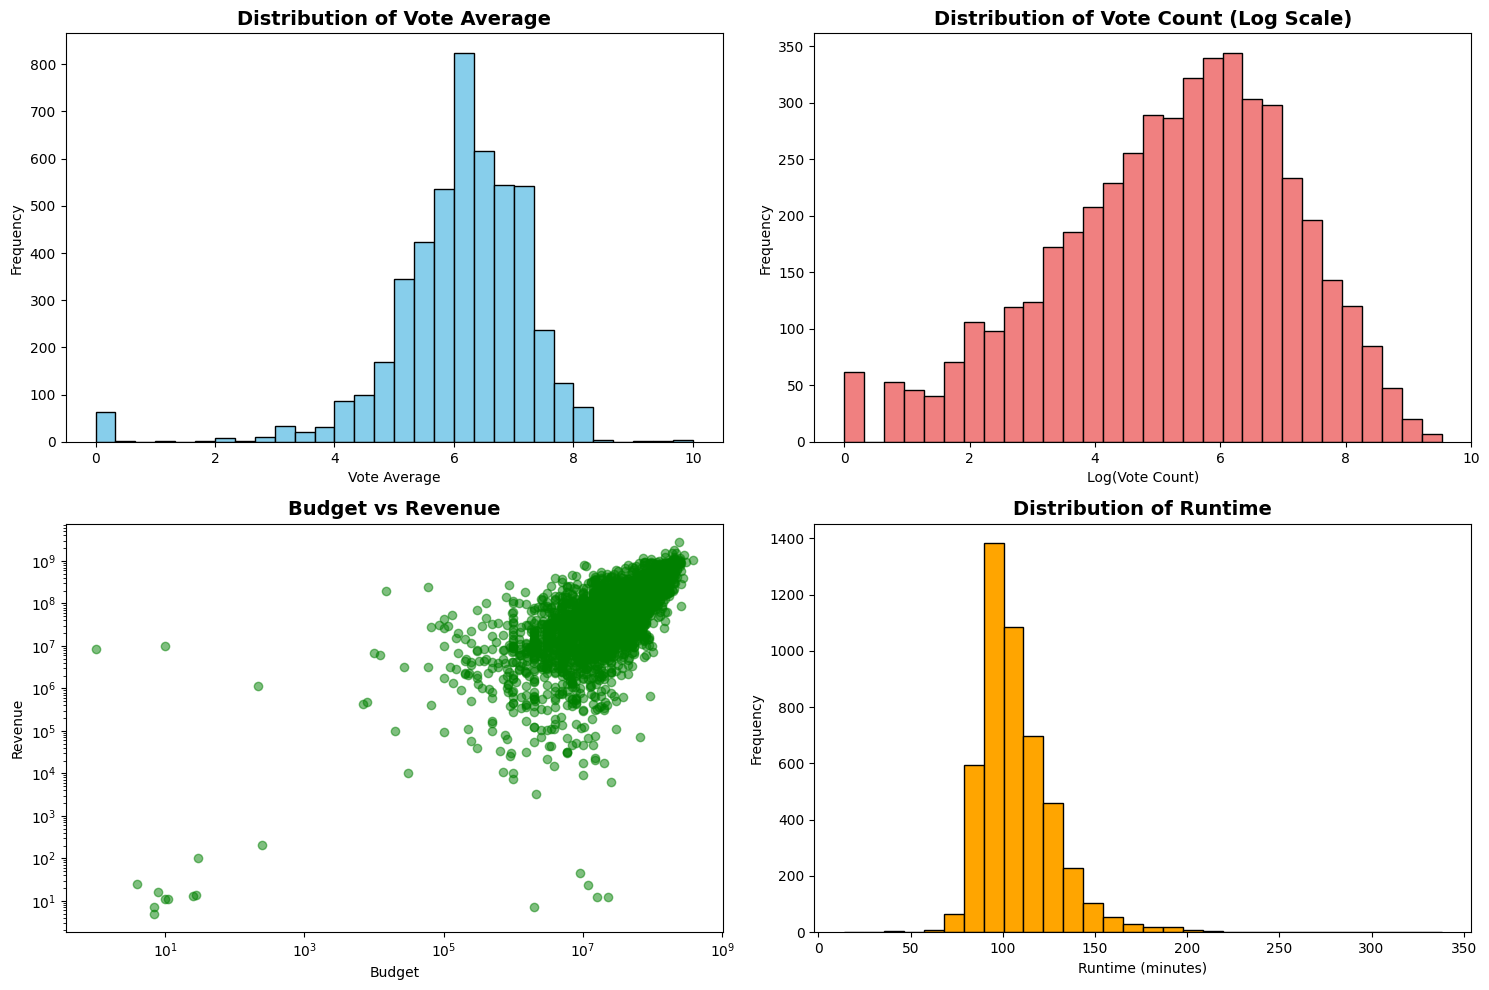

In [13]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Vote average distribution
axes[0, 0].hist(movies['vote_average'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Vote Average', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Vote Average')
axes[0, 0].set_ylabel('Frequency')

# Vote count distribution (log scale)
axes[0, 1].hist(np.log1p(movies['vote_count']), bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of Vote Count (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log(Vote Count)')
axes[0, 1].set_ylabel('Frequency')

# Budget vs Revenue
valid_data = movies[(movies['budget'] > 0) & (movies['revenue'] > 0)]
axes[1, 0].scatter(valid_data['budget'], valid_data['revenue'], alpha=0.5, color='green')
axes[1, 0].set_title('Budget vs Revenue', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Budget')
axes[1, 0].set_ylabel('Revenue')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')

# Runtime distribution
axes[1, 1].hist(movies[movies['runtime'] > 0]['runtime'], bins=30, color='orange', edgecolor='black')
axes[1, 1].set_title('Distribution of Runtime', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Runtime (minutes)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Plot 2: Correlation Matrix**

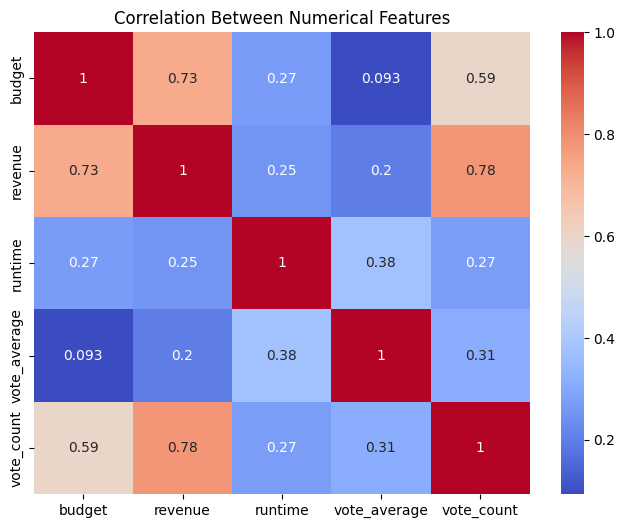

In [14]:
numeric_features = movies[['budget','revenue','runtime','vote_average','vote_count']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_features.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Features")
plt.show()

In [15]:
# Tabular analysis of top rated movies
top_rated = movies[['title','vote_average','vote_count']] \
            .sort_values(by='vote_average', ascending=False)

top_rated.head(10)

,title,vote_average,vote_count
3519,Stiff Upper Lips,10.0,1
4247,Me You and Five Bucks,10.0,2
4045,"Dancer, Texas Pop. 81",10.0,1
4662,Little Big Top,10.0,1
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
2970,There Goes My Baby,8.5,2
1881,The Shawshank Redemption,8.5,8205
2796,The Prisoner of Zenda,8.4,11
3337,The Godfather,8.4,5893


In [16]:
# Tabular analysis of movie with the most high revenue
top_revenue = movies[['title','revenue']] \
              .sort_values(by='revenue', ascending=False)

top_revenue.head(10)

,title,revenue
0,Avatar,2787965087
25,Titanic,1845034188
16,The Avengers,1519557910
28,Jurassic World,1513528810
44,Furious 7,1506249360
7,Avengers: Age of Ultron,1405403694
124,Frozen,1274219009
31,Iron Man 3,1215439994
546,Minions,1156730962
26,Captain America: Civil War,1153304495


In [17]:
# Genre analysis
def extract_genres(text):
    genres = ast.literal_eval(text)
    return [g['name'] for g in genres]

movies['genres_list'] = movies['genres'].apply(extract_genres)

movies[['title','genres_list']].head()

,title,genres_list
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]"
2,Spectre,"[Action, Adventure, Crime]"
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]"
4,John Carter,"[Action, Adventure, Science Fiction]"


**Plot 3: Genre Distribution**

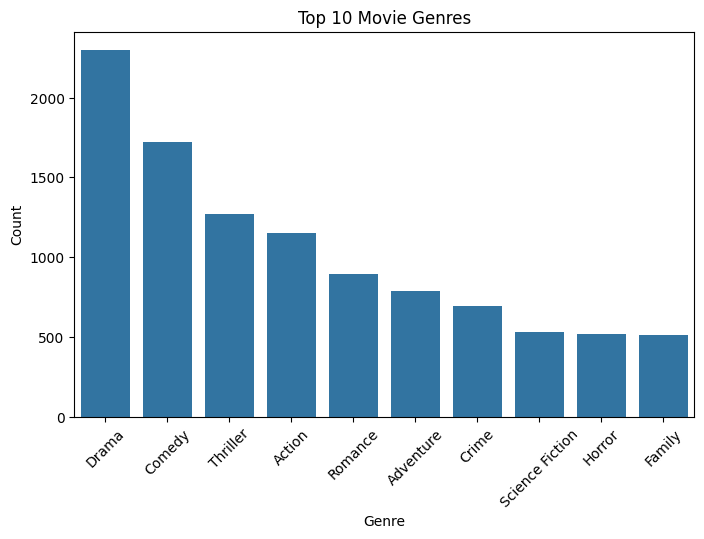

In [18]:
all_genres = sum(movies['genres_list'], [])
genre_counts = Counter(all_genres)

genre_df = pd.DataFrame(genre_counts.most_common(10), columns=['Genre','Count'])

plt.figure(figsize=(8,5))
sns.barplot(data=genre_df, x='Genre', y='Count')
plt.title("Top 10 Movie Genres")
plt.xticks(rotation=45)
plt.show()

### 6. DATA PREPROCESSING

In [19]:
# Merge datasets
movies = movies.merge(credits, left_on='id', right_on='movie_id', how='left')
print(f"✅ Merged dataset shape: {movies.shape}")

✅ Merged dataset shape: (4803, 25)


In [20]:
# Select relevant columns
movies = movies[['id', 'title_x', 'overview', 'genres', 'keywords', 
                 'cast', 'crew', 'vote_average', 'vote_count', 'popularity']]

movies.rename(columns={'title_x': 'title'}, inplace=True)

In [21]:
# Drop rows with missing overview
movies = movies.dropna(subset=['overview'])

# Reset index
movies = movies.reset_index(drop=True)

print(f"✅ Cleaned dataset shape: {movies.shape}")

✅ Cleaned dataset shape: (4800, 10)


In [22]:
# Function to extract names from JSON-like strings
def extract_names(text, key='name', limit=3):
    """Extract names from JSON-like strings"""
    if pd.isna(text):
        return []
    try:
        data = ast.literal_eval(text)
        return [item[key] for item in data[:limit]]
    except:
        return []

In [23]:
# Extract director from crew
def get_director(crew_str):
    if pd.isna(crew_str):
        return []
    try:
        crew = ast.literal_eval(crew_str)
        for member in crew:
            if member.get('job') == 'Director':
                return [member.get('name', '')]
    except:
        pass
    return []

In [24]:
# Extract genres
movies['genres_list'] = movies['genres'].apply(lambda x: extract_names(x, 'name', 5))

# Extract keywords
movies['keywords_list'] = movies['keywords'].apply(lambda x: extract_names(x, 'name', 5))

# Extract cast (top 3 actors)
movies['cast_list'] = movies['cast'].apply(lambda x: extract_names(x, 'name', 3))

# Extract director
movies['director'] = movies['crew'].apply(get_director)

In [25]:
print("✅ Feature extraction completed!")
display(movies[['title', 'genres_list', 'keywords_list', 'cast_list', 'director']].head())

✅ Feature extraction completed!


,title,genres_list,keywords_list,cast_list,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi6]","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [26]:
# Clean text function
def clean_text(text_list):
    """Convert list to lowercase string without spaces"""
    if isinstance(text_list, list):
        return ' '.join([str(item).lower().replace(' ', '') for item in text_list])
    return ''

In [27]:
# Create combined features for content-based filtering
movies['genres_clean'] = movies['genres_list'].apply(clean_text)
movies['keywords_clean'] = movies['keywords_list'].apply(clean_text)
movies['cast_clean'] = movies['cast_list'].apply(clean_text)
movies['director_clean'] = movies['director'].apply(clean_text)
movies['overview'] = movies['overview'].str.lower()

In [28]:
# Combine all features into one 'soup'
movies['soup'] = (movies['overview'].fillna('') + ' ' + 
                  movies['genres_clean'] + ' ' + 
                  movies['keywords_clean'] + ' ' + 
                  movies['cast_clean'] + ' ' + 
                  movies['director_clean'])

In [29]:
# Drop old columns
movies = movies.drop(columns=['genres','keywords','cast','crew'])

In [30]:
print("✅ Text preprocessing completed!")
print("\nExample 'soup':")
print(movies.iloc[0]['soup'][:300] + '...')

✅ Text preprocessing completed!

Example 'soup':
in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society samworthington zoesaldana sigourney...


In [31]:
print("Final dataset shape:", movies.shape)
movies[['title','soup']].head()

Final dataset shape: (4800, 15)


,title,soup
0,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,Spectre,a cryptic message from bond’s past sends him o...
3,The Dark Knight Rises,following the death of district attorney harve...
4,John Carter,"john carter is a war-weary, former military ca..."


### 7. CONTENT-BASED RECOMMENDATION SYSTEM

This model uses TF-IDF vectorization on combined movie features (overview, genres, keywords, cast, and director) to represent each movie as a numerical vector. Cosine similarity is then used to measure the similarity between movies and generate recommendations based on
the most similar content.

In [32]:
# Create TF-IDF matrix
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['soup'])

print(f"✅ TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"Number of movies: {tfidf_matrix.shape[0]}")
print(f"Number of features: {tfidf_matrix.shape[1]}")

✅ TF-IDF Matrix shape: (4800, 5000)
Number of movies: 4800
Number of features: 5000


In [33]:
# Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"✅ Cosine Similarity Matrix shape: {cosine_sim.shape}")
print(f"\nSimilarity range: [{cosine_sim.min():.4f}, {cosine_sim.max():.4f}]")

✅ Cosine Similarity Matrix shape: (4800, 4800)

Similarity range: [0.0000, 1.0000]


In [34]:
# Create reverse mapping of indices and movie titles
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_content_recommendations(title, cosine_sim=cosine_sim, top_n=10):
    """
    Get movie recommendations based on content similarity
    
    Parameters:
    -----------
    title : str
        Movie title
    cosine_sim : array
        Cosine similarity matrix
    top_n : int
        Number of recommendations to return
    
    Returns:
    --------
    DataFrame with recommended movies and similarity scores
    """
    try:
        if title not in indices:
            return pd.DataFrame({'error': [f"Movie '{title}' not found in database"]})

        idx = indices[title]

        sim_scores = cosine_sim[idx].argsort()[::-1]

        movie_indices = sim_scores[1:top_n+1]

        similarity_scores = cosine_sim[idx][movie_indices]

        recommendations = movies.iloc[movie_indices][
            ['title', 'genres_list', 'vote_average', 'popularity']
        ].copy()

        recommendations['similarity_score'] = similarity_scores
        recommendations['rank'] = range(1, len(recommendations) + 1)

        return recommendations[['rank','title','genres_list','vote_average','similarity_score']]
        
    except KeyError:
        return pd.DataFrame({'error': [f"Movie '{title}' not found in database"]})

print("✅ Content-based recommendation function created!")

✅ Content-based recommendation function created!


In [35]:
# Test the recommendation system
test_movie = 'The Dark Knight'

print(f"\n🎬 Movies similar to '{test_movie}':")
print("="*80)

recommendations = get_content_recommendations(test_movie, top_n=10)
display(recommendations)


🎬 Movies similar to 'The Dark Knight':


,rank,title,genres_list,vote_average,similarity_score
3,1,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",7.6,0.393490
119,2,Batman Begins,"[Action, Crime, Drama]",7.5,0.321081
428,3,Batman Returns,"[Action, Fantasy]",6.6,0.288221
299,4,Batman Forever,"[Action, Crime, Fantasy]",5.2,0.260029
3853,5,"Batman: The Dark Knight Returns, Part 2","[Action, Animation]",7.9,0.259087
210,6,Batman & Robin,"[Action, Crime, Fantasy]",4.2,0.196048
1359,7,Batman,"[Fantasy, Action]",7.0,0.176589
9,8,Batman v Superman: Dawn of Justice,"[Action, Adventure, Fantasy]",5.7,0.157342
2507,9,Slow Burn,"[Mystery, Crime, Drama, Thriller]",5.5,0.155120
4635,10,Amidst the Devil's Wings,"[Drama, Action, Crime]",0.0,0.147594


### 8. WEIGHTED RATING SYSTEM

Using formula IMDB for weighted rating:

$$WR = \frac{v}{v+m} \times R + \frac{m}{v+m} \times C$$

Where:
- **WR**: Weighted Rating
- **R**: Average rating for the movie
- **v**: Number of votes for the movie
- **m**: Minimum votes required (we'll use 90th percentile)
- **C**: Mean rating across all movies

In [36]:
# Calculate weighted rating
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.90)

print(f"Mean vote average (C): {C:.2f}")
print(f"Minimum votes required (m): {m:.0f}")

Mean vote average (C): 6.09
Minimum votes required (m): 1841


In [37]:
# Filter movies with minimum votes
qualified_movies = movies[movies['vote_count'] >= m].copy()
print(f"\nNumber of qualified movies: {len(qualified_movies)} out of {len(movies)}")


Number of qualified movies: 480 out of 4800


In [38]:
# Weighted rating formula
def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v/(v+m) * R) + (m/(m+v) * C)

In [39]:
qualified_movies['weighted_score'] = (
    (qualified_movies['vote_count']/(qualified_movies['vote_count']+m) * qualified_movies['vote_average']) +
    (m/(m+qualified_movies['vote_count']) * C)
)

# Sort by weighted score
top_movies = qualified_movies.sort_values('weighted_score', ascending=False)

top_movies = top_movies.reset_index(drop=True)
print("\n🏆 TOP 20 MOVIES (by Weighted Rating):")
print("="*80)
display(top_movies[['title','vote_average','vote_count','popularity','weighted_score']].head(20))


🏆 TOP 20 MOVIES (by Weighted Rating):


,title,vote_average,vote_count,popularity,weighted_score
0,The Shawshank Redemption,8.5,8205,136.747729,8.058866
1,Fight Club,8.3,9413,146.757391,7.938935
2,The Dark Knight,8.2,12002,187.322927,7.919763
3,Pulp Fiction,8.3,8428,121.463076,7.904302
4,Inception,8.1,13752,167.583710,7.863021
5,The Godfather,8.4,5893,143.659698,7.850800
6,Interstellar,8.1,10867,724.247784,7.809222
7,Forrest Gump,8.2,7927,138.133331,7.802855
8,The Lord of the Rings: The Return of the King,8.1,8064,123.630332,7.726936
9,The Empire Strikes Back,8.2,5879,78.517830,7.697500


### 9. HYBRID RECOMMENDATION SYSTEM

Combines content-based filtering with weighted rating for better recommendations

In [40]:
def get_hybrid_recommendations(title, top_n=10, percentile=0.70):
    """
    Hybrid recommendation combining content similarity and weighted rating
    
    Parameters:
    -----------
    title : str
        Movie title
    top_n : int
        Number of recommendations
    percentile : float
        Vote count percentile threshold
    
    Returns:
    --------
    DataFrame with hybrid recommendations
    """
    content_recs = get_content_recommendations(title, top_n=50)

    if 'error' in content_recs.columns:
        return content_recs

    rec_indices = movies[movies['title'].isin(content_recs['title'])].index

    rec_movies = movies.loc[rec_indices].copy()

    m_hybrid = movies['vote_count'].quantile(percentile)

    qualified_recs = rec_movies[rec_movies['vote_count'] >= m_hybrid].copy()

    qualified_recs['weighted_score'] = (
        (qualified_recs['vote_count']/(qualified_recs['vote_count']+m) * qualified_recs['vote_average']) +
        (m/(m+qualified_recs['vote_count']) * C)
    )

    hybrid = content_recs.merge(
        qualified_recs[['title','weighted_score']],
        on='title',
        how='inner'
    )

    hybrid['hybrid_score'] = (
        0.7 * hybrid['similarity_score'] +
        0.3 * (hybrid['weighted_score']/10)
    )

    hybrid = hybrid.sort_values('hybrid_score', ascending=False).head(top_n)

    hybrid['rank'] = range(1, len(hybrid)+1)

    return hybrid[['rank','title','genres_list','vote_average','similarity_score','weighted_score','hybrid_score']]

print("✅ Hybrid recommendation function created!")

✅ Hybrid recommendation function created!


In [41]:
# Test hybrid recommendations
test_movie = 'The Dark Knight'

print(f"\n🎬 Hybrid Recommendations for '{test_movie}':")
print("="*100)

hybrid_recs = get_hybrid_recommendations(test_movie, top_n=10)
display(hybrid_recs)


🎬 Hybrid Recommendations for 'The Dark Knight':


,rank,title,genres_list,vote_average,similarity_score,weighted_score,hybrid_score
0,1,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",7.6,0.393490,7.346536,0.495839
1,2,Batman Begins,"[Action, Crime, Drama]",7.5,0.321081,7.218418,0.441309
2,3,Batman Returns,"[Action, Fantasy]",6.6,0.288221,6.334330,0.391785
3,4,Batman Forever,"[Action, Crime, Fantasy]",5.2,0.260029,5.692333,0.352790
5,5,Batman,"[Fantasy, Action]",7.0,0.176589,6.575822,0.320887
4,6,Batman & Robin,"[Action, Crime, Fantasy]",4.2,0.196048,5.269329,0.295313
7,7,Sherlock Holmes: A Game of Shadows,"[Adventure, Action, Crime, Mystery]",7.0,0.125766,6.708398,0.289288
12,8,The Prestige,"[Drama, Mystery, Thriller]",8.0,0.088090,7.436605,0.284761
6,9,Batman v Superman: Dawn of Justice,"[Action, Adventure, Fantasy]",5.7,0.157342,5.781785,0.283593
17,10,Inglourious Basterds,"[Drama, Action, Thriller, War]",7.9,0.080394,7.497753,0.281208


### 10. KNN-BASED FILTERING

K-Nearest Neighbors searches for the most similar movies based on cosine distance in the TF-IDF feature space.
**Advantage:** No need to store the full N×N matrix — more memory efficient.

In [42]:
# Build KNN model on TF-IDF matrix
print("🔵 Building KNN model...")
knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
knn_model.fit(tfidf_matrix)

print(f"✅ KNN model built on matrix shape: {tfidf_matrix.shape}")


🔵 Building KNN model...
✅ KNN model built on matrix shape: (4800, 5000)


In [43]:
title_to_index = dict(zip(movies['title'], movies.index))

def get_knn_recommendations(title, movies=movies, knn=knn_model,
                            tfidf_mat=tfidf_matrix, top_n=10):
    """
    Recommendation using the K-Nearest Neighbors algorithm.

    Parameters:
    -----------
    title     : str        - Input movie title
    movies    : DataFrame  - Movie dataset
    knn       : NearestNeighbors - Fitted KNN model
    tfidf_mat : sparse matrix    - TF-IDF feature matrix
    top_n     : int        - Number of recommendations to return

    Returns:
    --------
    DataFrame containing recommended movies along with their similarity_score
    """
    try:
        idx = title_to_index[title]
        movie_vector = tfidf_matrix[idx]

        distances, indices = knn_model.kneighbors(
            movie_vector,
            n_neighbors=top_n + 1
        )

        neighbors = indices[0][1:]
        similarities = 1 - distances[0][1:]

        recs = movies.iloc[neighbors][
            ['title','genres_list','vote_average','popularity']
        ].copy()

        recs['similarity_score'] = similarities
        recs['rank'] = range(1, len(recs)+1)

        return recs[['rank','title','genres_list','vote_average','similarity_score']]

    except KeyError:
        return pd.DataFrame({'error':[f"{title} not found"]})

print("✅ KNN recommendation function created!")


✅ KNN recommendation function created!


In [44]:
# Test KNN recommendations
test_movie = 'The Dark Knight'

print(f"\n🔵 KNN Recommendations for '{test_movie}':")
print("="*80)

knn_recs = get_knn_recommendations(test_movie, top_n=10)
display(knn_recs)



🔵 KNN Recommendations for 'The Dark Knight':


,rank,title,genres_list,vote_average,similarity_score
3,1,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",7.6,0.393490
119,2,Batman Begins,"[Action, Crime, Drama]",7.5,0.321081
428,3,Batman Returns,"[Action, Fantasy]",6.6,0.288221
299,4,Batman Forever,"[Action, Crime, Fantasy]",5.2,0.260029
3853,5,"Batman: The Dark Knight Returns, Part 2","[Action, Animation]",7.9,0.259087
210,6,Batman & Robin,"[Action, Crime, Fantasy]",4.2,0.196048
1359,7,Batman,"[Fantasy, Action]",7.0,0.176589
9,8,Batman v Superman: Dawn of Justice,"[Action, Adventure, Fantasy]",5.7,0.157342
2507,9,Slow Burn,"[Mystery, Crime, Drama, Thriller]",5.5,0.155120
4635,10,Amidst the Devil's Wings,"[Drama, Action, Crime]",0.0,0.147594


### 11. COLLABORATIVE FILTERING (SVD)

Collaborative Filtering recommends movies based on user preference patterns.  
The TMDB dataset does not have real user data, so we **simulate** the user-item matrix  
from favorite genres + vote_average, then decompose it using **SVD (Singular Value Decomposition)**.


$$A (user × movie) ≈ U · Σ · Vᵀ$$

The reconstructed matrix contains latent rating predictions for each user-movie pair.

In [45]:
# Build simulated user-item matrix
print("🤝 Building Collaborative Filtering model (SVD)...")

np.random.seed(42)
n_movies = len(movies)
n_users  = 500

# Collect all genres
all_genres_list = []
for gl in movies['genres_list'].dropna():
    if isinstance(gl, list):
        all_genres_list.extend(gl)
unique_genres = list(set(all_genres_list)) if all_genres_list else ['Action', 'Drama', 'Comedy']

# Build rating matrix: each virtual user rates movies matching their genre preference
rating_matrix = np.zeros((n_users, n_movies))

for u in range(n_users):
    preferred = np.random.choice(unique_genres,
                                 size=np.random.randint(1, 4),
                                 replace=False).tolist()
    for i, row in movies.reset_index(drop=True).iterrows():
        gl = row['genres_list'] if isinstance(row['genres_list'], list) else []
        if any(g in gl for g in preferred):
            noise = np.random.normal(0, 0.5)
            user_bias = np.random.normal(0,0.3)
            rating_matrix[u, i] = max(0, min(10, row['vote_average'] + user_bias + noise))

print(f"✅ Rating matrix shape: {rating_matrix.shape}")
print(f"   Sparsity: {100 * (rating_matrix == 0).sum() / rating_matrix.size:.1f}%")


🤝 Building Collaborative Filtering model (SVD)...
✅ Rating matrix shape: (500, 4800)
   Sparsity: 76.8%


In [46]:
# SVD Decomposition
sparse_matrix = csr_matrix(rating_matrix, dtype=np.float64)

k = min(50, min(sparse_matrix.shape) - 1)   # number of latent factors
U, sigma, Vt = svds(sparse_matrix, k=k)
sigma_diag = np.diag(sigma)

# Reconstruct predicted ratings
predicted_ratings = np.dot(np.dot(U, sigma_diag), Vt)

print(f"✅ SVD completed — latent factors (k): {k}")
print(f"   U shape : {U.shape}")
print(f"   Σ shape : {sigma_diag.shape}")
print(f"   Vᵀ shape: {Vt.shape}")
print(f"   Predicted ratings matrix: {predicted_ratings.shape}")


✅ SVD completed — latent factors (k): 50
   U shape : (500, 50)
   Σ shape : (50, 50)
   Vᵀ shape: (50, 4800)
   Predicted ratings matrix: (500, 4800)


In [47]:
title_to_index = dict(zip(movies['title'], movies.index))

def get_collab_recommendations(title, movies=movies,
                               pred_ratings=predicted_ratings, top_n=10):
    """
    SVD-based Collaborative Filtering recommendation.

    Steps:
    1. Find the index of the input movie
    2. Identify the 50 'virtual users' who gave the highest ratings to that movie
    3. Compute the average predicted ratings from those users for all other movies
    4. Return the top-N movies with the highest average ratings

    Parameters:
    -----------
    title        : str        - Input movie title
    movies       : DataFrame  - Movie dataset
    pred_ratings : ndarray    - Reconstructed rating matrix from SVD
    top_n        : int        - Number of recommendations to return

    Returns:
    --------
    DataFrame containing recommended movies with a collab_score (0–1)
    """
    try:
        idx = title_to_index[title]
        movie_col = idx if idx < pred_ratings.shape[1] else 0
        
        # Find top users who rate this movie highly
        user_scores   = pred_ratings[:, movie_col]
        top_user_ids  = np.argsort(user_scores)[-50:]
        
        # Average their predicted ratings across all movies
        avg_ratings              = pred_ratings[top_user_ids, :].mean(axis=0)
        avg_ratings[movie_col]   = -1   # exclude input movie
        
        top_indices = np.argsort(avg_ratings)[::-1][:top_n]
        top_scores  = avg_ratings[top_indices]
        
        # Normalise to 0-1
        max_s       = top_scores.max() if top_scores.max() > 0 else 1
        norm_scores = top_scores / max_s
        
        valid       = [i for i in top_indices if i < len(movies)][:top_n]
        norm_scores = norm_scores[:len(valid)]
        
        recs = movies.iloc[valid][['title', 'genres_list', 'vote_average', 'popularity']].copy()
        recs['collab_score'] = norm_scores
        recs['rank']         = range(1, len(recs) + 1)
        return recs[['rank', 'title', 'genres_list', 'vote_average', 'collab_score']]
    
    except (IndexError, KeyError) as e:
        return pd.DataFrame({'error': [str(e)]})

print("✅ Collaborative Filtering recommendation function created!")


✅ Collaborative Filtering recommendation function created!


In [48]:
# Test Collaborative Filtering recommendations
test_movie = 'The Dark Knight'

print(f"\n🤝 Collaborative Filtering Recommendations for '{test_movie}':")
print("="*80)

collab_recs = get_collab_recommendations(test_movie, top_n=10)
display(collab_recs)



🤝 Collaborative Filtering Recommendations for 'The Dark Knight':


,rank,title,genres_list,vote_average,collab_score
1850,1,Scarface,"[Action, Crime, Drama, Thriller]",8.0,1.000000
3,2,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",7.6,0.956234
1456,3,Bound by Honor,"[Action, Crime, Drama, Thriller]",7.7,0.945509
2091,4,The Silence of the Lambs,"[Crime, Drama, Thriller]",8.1,0.924276
3453,5,The Usual Suspects,"[Drama, Crime, Thriller]",8.1,0.919904
2558,6,Drive,"[Drama, Action, Thriller, Crime]",7.4,0.914877
2958,7,Machine Gun McCain,"[Drama, Action, Thriller, Crime, Foreign]",7.3,0.905642
1051,8,Prisoners,"[Drama, Thriller, Crime]",7.9,0.905021
1052,9,Training Day,"[Action, Crime, Drama, Thriller]",7.3,0.903680
351,10,The Departed,"[Drama, Thriller, Crime]",7.9,0.895132


### 12. MODEL EVALUATION

In [49]:
# Genre-based evaluation
def evaluate_genre_match(original_movie, recommendations, movies_df=movies):
    """
    Calculate what percentage of recommendations share genres with original movie
    """
    try:
        original_genres = set(movies_df[movies_df['title'] == original_movie]['genres_list'].iloc[0])
        
        genre_matches = []
        for rec_title in recommendations['title']:
            rec_genres = set(movies_df[movies_df['title'] == rec_title]['genres_list'].iloc[0])
            overlap = len(original_genres.intersection(rec_genres))
            genre_matches.append(overlap / len(original_genres) if len(original_genres) > 0 else 0)
        
        return np.mean(genre_matches) * 100
    except Exception as e:
        print(e)
        return 0

In [50]:
# Test on multiple movies — all 4 models
test_movies = ['The Dark Knight', 'Inception', 'The Matrix', 'Toy Story', 'Avatar']
evaluation_results = []

In [51]:
for movie in test_movies:
    try:
        content_recs = get_content_recommendations(movie, top_n=10)
        knn_recs     = get_knn_recommendations(movie, top_n=10)
        collab_recs  = get_collab_recommendations(movie, top_n=10)
        hybrid_recs  = get_hybrid_recommendations(movie, top_n=10)

        content_score = evaluate_genre_match(movie, content_recs)
        knn_score     = evaluate_genre_match(movie, knn_recs)    if 'error' not in knn_recs.columns    else 0
        collab_score  = evaluate_genre_match(movie, collab_recs) if 'error' not in collab_recs.columns else 0
        hybrid_score  = evaluate_genre_match(movie, hybrid_recs) if hybrid_recs is not None            else 0

        evaluation_results.append({
            'Movie':                         movie,
            'Content-Based Genre Match (%)': content_score,
            'KNN Genre Match (%)':           knn_score,
            'Collaborative Filtering (%)':   collab_score,
            'Hybrid Genre Match (%)':        hybrid_score,
        })
    except Exception as e:
        print(f"Error processing {movie}: {e}")

In [52]:
# Convert to DataFrame
eval_df = pd.DataFrame(evaluation_results)

print("\n📊 EVALUATION RESULTS:")
print("="*90)
display(eval_df)

cols = ['Content-Based Genre Match (%)', 'KNN Genre Match (%)',
        'Collaborative Filtering (%)',    'Hybrid Genre Match (%)']

print("\n✅ Average Genre Match per Model:")
for c in cols:
    print(f"   {c}: {eval_df[c].mean():.2f}%")


📊 EVALUATION RESULTS:


,Movie,Content-Based Genre Match (%),KNN Genre Match (%),Collaborative Filtering (%),Hybrid Genre Match (%)
0,The Dark Knight,52.500000,52.500000,90.0,52.500000
1,Inception,32.000000,32.000000,78.0,26.000000
2,The Matrix,65.000000,65.000000,100.0,70.000000
3,Toy Story,43.333333,43.333333,100.0,36.666667
4,Avatar,40.000000,40.000000,85.0,45.000000



✅ Average Genre Match per Model:
   Content-Based Genre Match (%): 46.57%
   KNN Genre Match (%): 46.57%
   Collaborative Filtering (%): 90.60%
   Hybrid Genre Match (%): 46.03%


**Plot 4: All 4 Models Recommendation Performance**

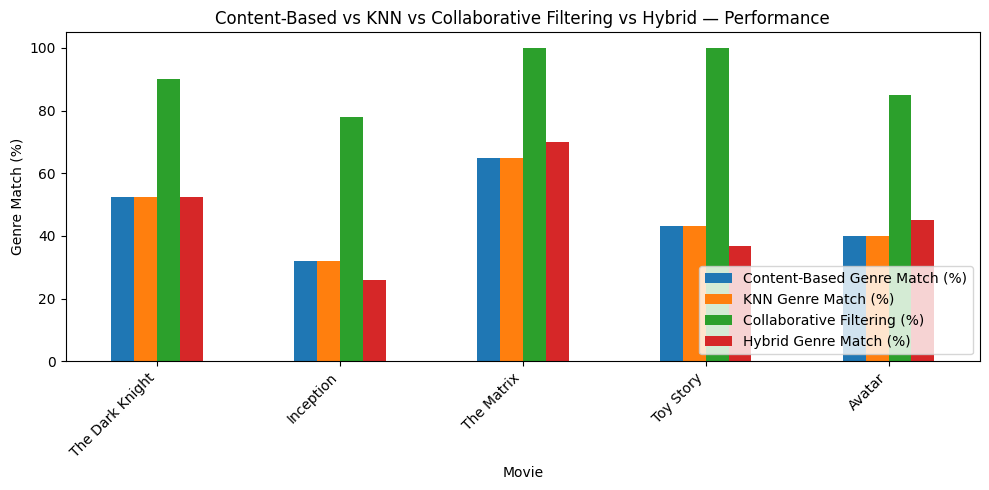

In [53]:
# Plot 4: All 4 Models Recommendation Performance
eval_df.set_index('Movie')[cols].plot(kind='bar', figsize=(10, 5))
plt.ylabel("Genre Match (%)")
plt.title("Content-Based vs KNN vs Collaborative Filtering vs Hybrid — Performance")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 13. MODEL COMPARISON

In [54]:
# Compare all 4 models 
test_movies_compare = ['The Dark Knight', 'Inception', 'Toy Story']

print("\n📊 COMPARISON: Content-Based vs KNN vs Collaborative Filtering vs Hybrid")
print("="*100)

for movie in test_movies_compare:
    print(f"\n🎬  {movie}")
    print("-"*80)
    
    cb_recs     = get_content_recommendations(movie, top_n=5)
    knn_recs    = get_knn_recommendations(movie, top_n=5)
    cf_recs     = get_collab_recommendations(movie, top_n=5)
    hybrid_recs = get_hybrid_recommendations(movie, top_n=5)
    
    if cb_recs is not None and 'error' not in cb_recs.columns:
        cb_titles     = cb_recs['title'].tolist()
        knn_titles    = knn_recs['title'].tolist() if 'error' not in knn_recs.columns else []
        cf_titles     = cf_recs['title'].tolist()  if 'error' not in cf_recs.columns  else []
        hybrid_titles = hybrid_recs['title'].tolist() if hybrid_recs is not None else []
        
        max_len = max(len(cb_titles), len(knn_titles), len(cf_titles), len(hybrid_titles))
        for i in range(max_len):
            cb_t = cb_titles[i]     if i < len(cb_titles)     else '-'
            knn_t= knn_titles[i]    if i < len(knn_titles)    else '-'
            cf_t = cf_titles[i]     if i < len(cf_titles)     else '-'
            hy_t = hybrid_titles[i] if i < len(hybrid_titles) else '-'
            print(f"  {i+1}. CB: {cb_t[:30]:<32} | KNN: {knn_t[:30]:<32} | CF: {cf_t[:30]:<32} | Hybrid: {hy_t[:30]}")



📊 COMPARISON: Content-Based vs KNN vs Collaborative Filtering vs Hybrid

🎬  The Dark Knight
--------------------------------------------------------------------------------
  1. CB: The Dark Knight Rises            | KNN: The Dark Knight Rises            | CF: Scarface                         | Hybrid: The Dark Knight Rises
  2. CB: Batman Begins                    | KNN: Batman Begins                    | CF: The Dark Knight Rises            | Hybrid: Batman Begins
  3. CB: Batman Returns                   | KNN: Batman Returns                   | CF: Bound by Honor                   | Hybrid: Batman Returns
  4. CB: Batman Forever                   | KNN: Batman Forever                   | CF: The Silence of the Lambs         | Hybrid: Batman Forever
  5. CB: Batman: The Dark Knight Return   | KNN: Batman: The Dark Knight Return   | CF: The Usual Suspects               | Hybrid: Batman

🎬  Inception
--------------------------------------------------------------------------------
  1

In [55]:
# Genre match evaluation for all 4 models
def evaluate_genre_match(original_movie, recommendations, movies_df=movies):
    try:
        original_genres = set(movies_df[movies_df['title'] == original_movie]['genres_list'].iloc[0])
        matches = []
        for title in recommendations['title']:
            rec_genres = set(movies_df[movies_df['title'] == title]['genres_list'].iloc[0])
            overlap    = len(original_genres & rec_genres)
            matches.append(overlap / len(original_genres) if original_genres else 0)
        return np.mean(matches) * 100
    except Exception:
        return 0

In [56]:
test_movies_eval = ['The Dark Knight', 'Inception', 'The Matrix', 'Toy Story', 'Avatar']

In [57]:
results = []

for movie in test_movies_eval:
    try:
        cb   = get_content_recommendations(movie, top_n=10)
        knn  = get_knn_recommendations(movie, top_n=10)
        cf   = get_collab_recommendations(movie, top_n=10)
        hyb  = get_hybrid_recommendations(movie, top_n=10)
        results.append({
            'Movie':                          movie,
            'Content-Based Genre Match (%)':  evaluate_genre_match(movie, cb)  if cb is not None else 0,
            'KNN Genre Match (%)':            evaluate_genre_match(movie, knn) if knn is not None else 0,
            'Collaborative Filtering (%)':    evaluate_genre_match(movie, cf)  if cf is not None else 0,
            'Hybrid Genre Match (%)':         evaluate_genre_match(movie, hyb) if hyb is not None else 0,
        })
    except Exception as e:
        print(f"Error for {movie}: {e}")


In [58]:
eval_df = pd.DataFrame(results)
print("\n📊 EVALUATION RESULTS (Genre Match %):")
print("="*90)
display(eval_df)


📊 EVALUATION RESULTS (Genre Match %):


,Movie,Content-Based Genre Match (%),KNN Genre Match (%),Collaborative Filtering (%),Hybrid Genre Match (%)
0,The Dark Knight,52.500000,52.500000,90.0,52.500000
1,Inception,32.000000,32.000000,78.0,26.000000
2,The Matrix,65.000000,65.000000,100.0,70.000000
3,Toy Story,43.333333,43.333333,100.0,36.666667
4,Avatar,40.000000,40.000000,85.0,45.000000


In [59]:
cols = ['Content-Based Genre Match (%)', 'KNN Genre Match (%)',
        'Collaborative Filtering (%)',    'Hybrid Genre Match (%)']
print("\n✅ Average Genre Match per Model:")
for c in cols:
    print(f"   {c}: {eval_df[c].mean():.2f}%")


✅ Average Genre Match per Model:
   Content-Based Genre Match (%): 46.57%
   KNN Genre Match (%): 46.57%
   Collaborative Filtering (%): 90.60%
   Hybrid Genre Match (%): 46.03%


### 14. SAVE MODEL

In [60]:
deployment_data = {
    # existing
    'movies':     movies[['id', 'title', 'overview', 'genres_list', 'cast_list',
                           'director', 'vote_average', 'vote_count', 'popularity', 'soup']],
    'cosine_sim': cosine_sim,
    'indices':    indices,
    'm':          m,
    'C':          C,
    # new
    'knn_model':        knn_model,
    'tfidf_matrix':     tfidf_matrix,
    'predicted_ratings': predicted_ratings,
}

with open('movie_recommendation_model.pkl', 'wb') as f:
    pickle.dump(deployment_data, f)

size_mb = os.path.getsize('movie_recommendation_model.pkl') / (1024 * 1024)
print(f"✅ Updated model saved → movie_recommendation_model.pkl ({size_mb:.2f} MB)")
print(f"   Includes: Content-Based, KNN, Collaborative Filtering (SVD)")


✅ Updated model saved → movie_recommendation_model.pkl (201.14 MB)
   Includes: Content-Based, KNN, Collaborative Filtering (SVD)


### 15. CONCLUSION

This project implemented and compared four recommendation approaches:
Content-Based Filtering, KNN-Based Filtering, Collaborative Filtering (SVD),
and a Hybrid Recommendation System.

---

Key Achievements
- Successfully built a complete movie recommendation pipeline using multiple
  recommendation techniques.
- Implemented TF-IDF based content representation to capture movie similarity.
- Applied K-Nearest Neighbors to efficiently retrieve similar movies without
  computing the full similarity matrix.
- Simulated a user–item interaction matrix and applied SVD to generate latent
  user preferences for Collaborative Filtering.
- Developed a Hybrid model that combines content similarity with weighted
  movie ratings to improve recommendation quality.

---

Model Insights
- Content-Based and KNN approaches produced similar results because both rely
  on the same TF-IDF feature space and cosine similarity for measuring movie
  similarity.
- Collaborative Filtering achieved the highest genre match score (≈90%),
  demonstrating the power of latent preference modeling in capturing deeper
  relationships between movies.
- The Hybrid model helps balance similarity and popularity, making
  recommendations more reliable for real-world applications.

---

Business Impact
- Personalized recommendation systems can significantly improve user
  engagement and retention in streaming platforms.
- Accurate recommendations help users discover relevant content faster,
  reducing search time and increasing watch time.
- Hybrid recommendation strategies provide a practical solution for
  production systems by combining multiple signals such as content similarity,
  popularity, and collaborative patterns.

### Next Steps: Deploy to Streamlit

Run file `app.py` using command:
```bash
streamlit run app.py
```